<a href="https://colab.research.google.com/github/funviction/pract/blob/main/%D0%9B%D0%A02_2_2_%D0%A4%D1%96%D0%BD%D1%8C%D0%BA%D0%BE_3_9_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [41]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Passengerld: Унікальний ідентифікатор для кожного пасажира.

Survived: У цьому стовпці вказується, чи вижив пасажир (1), чи ні (0).

Pclass (Клас квитка): Показник соціально-економічного статусу, де 1 найвищий клас, а 3 найнижчий.

Name: Ім'я пасажира.

Sex. Стать пасажира.

Age: Вік пасажира. (Примітка: У цьому стовпці можуть бути відсутні значення.)

SibSp: Кількість братів і сестер або подружжя пасажира на борту «Титаніка».

Parch: Кількість батьків або дітей пасажира на борту «Титаніка».

Ticket: Номер квитка.

Fare. Сума грошей, яку пасажир сплатив за квиток.

2. Визначити розмір датасета.
3. Визначити тип даних.

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Визначення дублікатів.

In [43]:
df.duplicated().sum()

np.int64(0)

4. Визначити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [44]:
#Check for missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Вирішили пропущені значення замінити на медіану

In [45]:
#Fill missing values
# Заповнення пропущених значень у стовпчику Age медіаною
df['Age'] = df['Age'].fillna(df['Age'].median(skipna=True))

# Видалення стовпчиків Cabin та Embarked
df.drop(['Cabin', 'Embarked'], axis=1, inplace=True)

5. Ще раз перевірити наявність пропущених значень.

In [46]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## 6. Сформувати датасет з обраними стовпцями: ['Survived', 'Place', 'Sex', 'Age', 'Fare']

In [47]:
# Clean the dataset of unnecessary columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


7. Замінити бінарні ознаки (Стать) на 0 і 1

In [48]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [49]:
# Convert categorical data to numerical data
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(f'Data types of the dataset:\n{df.dtypes}')

Data types of the dataset:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


/tmp/ipykernel_825/909601743.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


8. Вивести описову статистику датасету describe()

In [50]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


9. Ще раз перевірити кількість пропущених даних (впевнитись, що їх немає).

In [51]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


10. Вивести 5 перших рядків датасету.

In [52]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


11. Вивести 5 останніх рядків датасету.

In [53]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


## 12. Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?

In [54]:
survival_by_sex = df.groupby('Sex') ['Survived'].mean() *100

print(f'Share of survived males: {survival_by_sex[0]:.2f}%')
print (f'Share of survived females: {survival_by_sex[1]:.2f}%')

Share of survived males: 18.89%
Share of survived females: 74.20%


Так, між чоловіками та жінками спостерігається суттєва різниця у виживанні. Відсоток виживших жінок (74.20%) майже в 4 рази перевищує відсоток виживших чоловіків (18.89%), що вказує на пріоритетність порятунку жінок під час евакуації.  

In [55]:
print(f'Correlation between sex and survival: {df["Sex"].corr(df["Survived"])}')

Correlation between sex and survival: 0.5433513806577555


2 варіант коду

In [56]:
# Calculate share of survivors by sex
male_survival_rate = df[(df['Sex'] == 0) & (df['Survived'] == 1)].shape[0] / df[df['Sex'] == 0].shape[0]
female_survival_rate = df[(df['Sex'] == 1) & (df['Survived'] == 1)].shape[0] / df[df['Sex'] == 1].shape[0]

print(f'Share of survived males: {male_survival_rate * 100:.2f}%')
print(f'Share of survived females: {female_survival_rate * 100:.2f}%')
print(f'Correlation between sex and survival: {df["Sex"].corr(df["Survived"]):.2f}')

Share of survived males: 18.89%
Share of survived females: 74.20%
Correlation between sex and survival: 0.54


13.Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?

In [57]:
class1_surv_rate = df[(df['Pclass'] == 1) & (df['Survived'] == 1)].shape[0] / df [df['Pclass'] == 1].shape[0]
class2_surv_rate = df[(df['Pclass'] == 2) & (df['Survived'] == 1)].shape[0] / df [df['Pclass'] == 2].shape[0]
class3_surv_rate = df[(df['Pclass'] == 3) & (df['Survived'] == 1)].shape[0] / df [df['Pclass'] == 3].shape[0]

print(f'Share of survived class 1 passengers {class1_surv_rate * 100:.2f}%')
print (f'Share of survived class 2 passengers {class2_surv_rate * 100:.2f}%')
print (f'Share of survived class 3 passengers {class3_surv_rate * 100:.2f}%')

Share of survived class 1 passengers 62.96%
Share of survived class 2 passengers 47.28%
Share of survived class 3 passengers 24.24%


Відсоток виживання для кожного класу становить:  
 1 клас: 62.96%  
  2 клас: 47.28%   
  3 клас: 24.24%   
  Найвищий рівень виживання мав 1 клас, де врятувалося 62.96% пасажирів.   

14.Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?

In [58]:
survived_mean_age = df [df['Survived'] == 1]['Age'].mean()
not_survived_mean_age = df [df['Survived'] == 0]['Age'].mean()

print(f'Mean age of survived passengers: {survived_mean_age:.2f}')
print(f'Mean age of not survived passengers: {not_survived_mean_age:.2f}')

Mean age of survived passengers: 28.29
Mean age of not survived passengers: 30.03


Середній вік пасажирів, які вижили, становить 28.29 років.   
Середній вік пасажирів, які не вижили, становить 30.03 років.   

Чи впливає вік на виживання:
Різниця у середньому віці між цими двома групами є відносно невеликою (менше двох років). Хоча пасажири, які вижили, були в середньому трохи молодшими, спираючись лише на цей загальний показник, не можна сказати про кардинальний вплив віку. (Проте, для більш точного висновку зазвичай проводять додатковий аналіз за віковими групами, наприклад, окремо розглядають дітей).

15.Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?

In [59]:
#Separate dataset in 4 buckets by Fare sorted in ascending order

df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)

#Find share of survivors in each bucket
for i in range(6):
  surv_rate = df [(df['Fare_Category'] == i) & (df['Survived'] == 1)].shape[0] / df[df['Fare_Category'] == i].shape[0]
  print(f'Share of survived passengers in bucket {i}: {surv_rate * 100:.2f}%')

Share of survived passengers in bucket 0: 20.51%
Share of survived passengers in bucket 1: 19.08%
Share of survived passengers in bucket 2: 36.69%
Share of survived passengers in bucket 3: 43.62%
Share of survived passengers in bucket 4: 41.78%
Share of survived passengers in bucket 5: 69.80%


/tmp/ipykernel_825/474442289.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)


Рівень виживання для кожної з 6 груп тарифів (від найнижчого до найвищого) становить:   
Група 0: 20.51%   
Група 1: 19.08%   
Група 2: 36.69%   
Група 3: 43.62%   
Група 4: 41.78%   
Група 5: 69.80%   

Як тариф впливав на шанси виживання:
Спостерігається чітка пряма залежність: чим вищий рівень тарифу, тим більші шанси на виживання. Пасажири з найдорожчими квитками (група 5) мали найвищий відсоток виживання — майже 70%, тоді як серед пасажирів з найдешевшими квитками (групи 0 та 1) вижило лише близько 19-20%.

16.Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?

In [60]:
#Find median fare for the class

for i in range(1, 4):
  median_fare = df [df['Pclass'] == i]['Fare'].median()
  print(f'Median fare for class {i}: {median_fare:.2f}')

Median fare for class 1: 60.29
Median fare for class 2: 14.25
Median fare for class 3: 8.05


Згідно з результатами виконання коду, медіанний тариф для кожного класу становить:   
1 клас: 60.29   
2 клас: 14.25   
3 клас: 8.05   

Так, між класами існує дуже значна різниця у тарифах. Вартість квитка 1 класу більш ніж у 4 рази перевищує вартість квитка 2 класу та в 7.5 разів — вартість квитка 3 класу.  

17. Як пов'язано середній вік пасажирів з виживанням? Відповідь дати аналітично чи графічно

<Axes: xlabel='Age', ylabel='Count'>

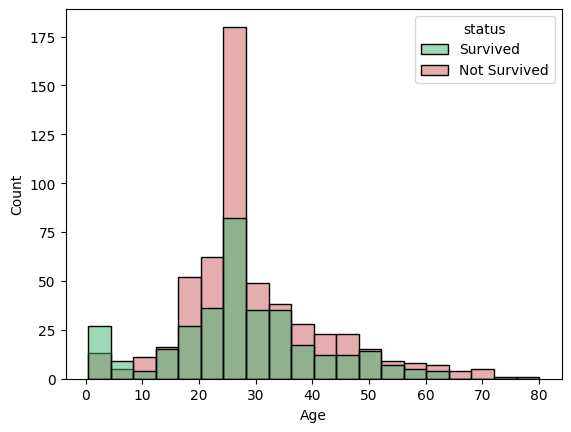

In [61]:
# Combine the data into a single DataFrame
df_survived = df [df['Survived'] == 1][['Age']]
df_survived['status'] = 'Survived'

df_not_survived = df [df['Survived'] == 0][['Age']]
df_not_survived['status'] = 'Not Survived'

df_combined = pd.concat([df_survived, df_not_survived])

#Plot the histogram with hue
sns.histplot(
    data=df_combined,
    x='Age',
    hue='status',
    bins=20,
    palette={'Survived': 'mediumseagreen', 'Not Survived': 'indianred'}
)

Гістограма наочно показує, що шанси на виживання сильно залежали від віку пасажирів.
Розподіл не є рівномірним, а має чіткий пік у діапазоні від 20 до 30 років.

Діти (0–10 років)
Для малюків віком до 5 років спостерігається унікальна для всього графіка ситуація: кількість врятованих (салатовий колір) помітно перевищує кількість загиблих (червоний). Ця тенденція зберігається і для дітей до 10 років, що підтверджує пріоритет їхнього порятунку під час евакуації.   

Молодь (15–30 років)
Це найбільша вікова група на борту, на яку припадає абсолютна більшість жертв. В інтервалі 20–30 років червоні стовпці досягають максимуму і сильно домінують над салатовими. Висока смертність тут пояснюється тим, що більшість цієї групи складали працездатні чоловіки та пасажири третього класу.   

Дорослі (30–50 років)
Після 30 років загальна кількість пасажирів на графіку поступово зменшується. Загиблих у кожному проміжку все ще більше, ніж врятованих, проте різниця між ними вже не така величезна, як серед двадцятирічних.   

Пасажири старшого віку (понад 50 років)
Людей старше 50 років було відносно мало. Цікаво, що в інтервалі 50–60 років кількість тих, хто вижив і загинув, є майже однаковою. Але після 65 років шанси на порятунок фактично зводяться до нуля, про що свідчать суцільні червоні стовпці, за винятком лише одного врятованого 80-річного пасажира.   

Візуалізація підтверджує, що вік був критичним фактором: найбільший захист отримали маленькі діти, тоді як основний відсоток загиблих - це молоді люди.

18. Дослідити комбінований вплив статі та класу на рівень виживаності пасажирів.

In [62]:
# Calculate survival rate per class per sex
for i in range(1, 4):
    for j in range(2):
        # Отримуємо кількість пасажирів певної статі та класу, які вижили
        survived_count = df[(df['Pclass'] == i) & (df['Sex'] == j) & (df['Survived'] == 1)].shape[0]
        # Отримуємо загальну кількість пасажирів цієї статі та класу
        total_count = df[(df['Pclass'] == i) & (df['Sex'] == j)].shape[0]

        surv_rate = survived_count / total_count

        gender = "male" if j == 0 else "female"
        print(f'Share of survived {gender} passengers in class {i}: {surv_rate * 100:.2f}%')

Share of survived male passengers in class 1: 36.89%
Share of survived female passengers in class 1: 96.81%
Share of survived male passengers in class 2: 15.74%
Share of survived female passengers in class 2: 92.11%
Share of survived male passengers in class 3: 13.54%
Share of survived female passengers in class 3: 50.00%


> **Висновок:**
>За результатами аналізу виявлено, що ймовірність порятунку пасажирів визначалася двома основними факторами: статтю та класом каюти.

Вплив статі: Жінки продемонстрували багаторазово вищий рівень виживання у всіх категоріях без винятку. Це є прямим наслідком дотримання протоколу першочергової евакуації вразливих груп.

Вплив класу: Соціальний статус формує чітку пряму залежність. Пасажири вищих класів (особливо першого) мали пріоритетний доступ до рятувальних шлюпок, тому їхні шанси на порятунок були значно вищими порівняно з пасажирами найдешевшого третього класу, незалежно від статевої приналежності.

Перетин цих двох параметрів дав полярні результати: абсолютний максимум врятованих зафіксовано серед жінок першого класу, тоді як критичний мінімум шансів на порятунок мали чоловіки, які подорожували третім класом.

19.Матриця кореляції

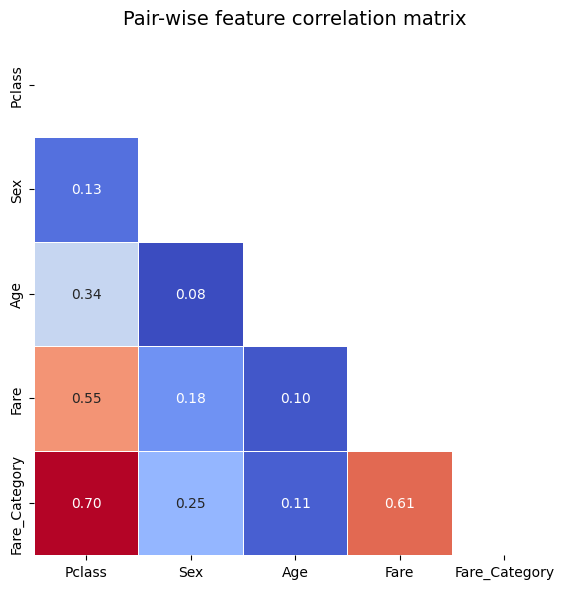

In [63]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

fig, ax = plt.subplots (figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidth=0.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Pair-wise feature correlation matrix", fontsize=14)
plt.tight_layout()
plt.show()

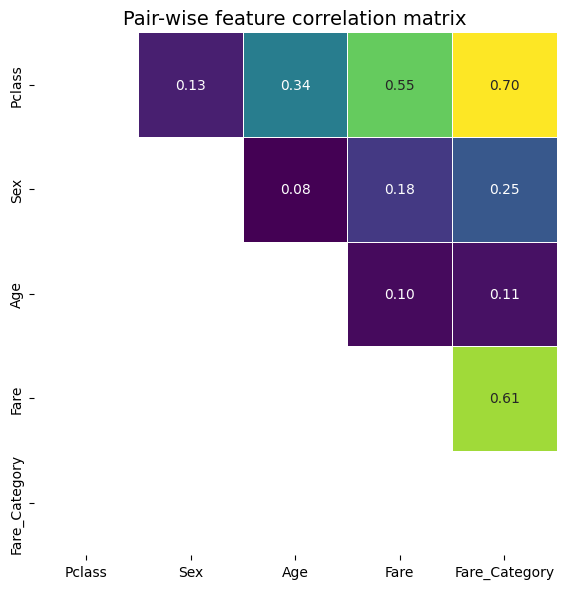

In [64]:
# Розрахунок матриці кореляцій
mtx = df.drop('Survived', axis=1, errors='ignore').corr(numeric_only=True).abs()

fig, ax = plt.subplots(figsize=(6, 6))

# Створюємо маску для нижнього трикутника та головної діагоналі (k=0 закриває і діагональ)
mask = np.tril(np.ones_like(mtx, dtype=bool), k=0)

sns.heatmap(
    mtx,
    cmap='viridis',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=mask,
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Pair-wise feature correlation matrix", fontsize=14)
plt.tight_layout()
plt.show()

Висновок:

Підсумовуючи всі етапи аналізу датасету, можна зробити висновок, що шанси на виживання пасажирів Титаніка залежали від цілком конкретних демографічних та соціальних факторів.

Найбільший вплив мали стать і вік: правило «жінки та діти в першу чергу» дійсно працювало на практиці. Це підтверджується дуже високим відсотком врятованих жінок та малюків, тоді як найбільше жертв припало на молодих чоловіків віком 20-30 років.

Другим критичним фактором став соціальний статус (клас каюти та вартість квитка). Пасажири 1-го класу з дорогими квитками мали набагато більші шанси на порятунок порівняно з пасажирами 3-го класу, незалежно від інших умов.

Щодо загальної структури даних, побудована матриця кореляцій підтвердила очікувані логічні зв'язки. Найбільш очевидна залежність виявилася між класом каюти та ціною квитка, а також між наявністю різних родичів на борту (брати/сестри та батьки/діти). Оскільки критичної кореляції між іншими числовими змінними ми не виявили, дані не страждають на мультиколінеарність. Це означає, що датасет є збалансованим, ознаки не дублюють одна одну, і цей набір даних повністю готовий для подальшого навчання моделей машинного навчання.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1.Реалізувати 2 способи завантаження файлу
(з комп'ютера та кагл)

In [66]:
from google.colab import files

uploaded = files.upload()

Saving bestsellers.csv to bestsellers (1).csv


2 спосіб завантаження файлу

In [67]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-top-50-bestselling-books-2009-2019' dataset.
Path to dataset files: /kaggle/input/amazon-top-50-bestselling-books-2009-2019


2. Прочитати csv файл (використовуючи функцію read_csv)

In [68]:
df = pd.read_csv(os.path.join(path, "bestsellers with categories.csv"))
df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


In [69]:
df= pd.read_csv('bestsellers.csv', encoding='latin1')
df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


Аналізований датасет містить вибірку з 550 спостережень (рядків), які описують популярні книги за 7 структурними атрибутами (стовпцями).

Змінні набору даних можна класифікувати за типами:

Текстові ознаки (рядкові):

Name — повна назва видання.

Author — ім'я та прізвище автора книги.

Числові ознаки:

User Rating (неперервна) — усереднений бал, сформований на основі оцінок читачів.

Reviews (дискретна) — загальна абсолютна кількість залишених користувацьких відгуків.

Price (неперервна) — фактична вартість примірника книги.

Year (дискретна часова) — рік, у якому видання було зафіксоване в рейтингу популярності.

Категоріальні ознаки:

Genre (бінарна номінальна) — жанрова класифікація, що розділяє датасет на два взаємовиключні класи: Fiction (художня література) та Non Fiction (нехудожня/документальна література).

3.Виведіть перших п'ять рядків (використовується функція head)

In [70]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


4.Виведіть розміри датасету (використовуйте метод shape)

In [71]:
df.shape

(550, 7)

5.Наявність дублікатів за назвою, видалити дублікати

In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
df = df.drop_duplicates(subset="Name")

In [74]:
df.shape

(351, 7)

6.Про скільки книг зберігає дані датасет?

550 книг (351 назва унікальна)

7.Перейменувати стовпці df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

In [76]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

df.head()

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


8.Виведіть кількість пропусків (na) у кожному зі стовпців (використовуйте функції isna та sum)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 351 entries, 0 to 546
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         351 non-null    object 
 1   author       351 non-null    object 
 2   user_rating  351 non-null    float64
 3   reviews      351 non-null    int64  
 4   price        351 non-null    int64  
 5   year         351 non-null    int64  
 6   genre        351 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 21.9+ KB


In [78]:
df.isna().sum()

,0
name,0
author,0
user_rating,0
reviews,0
price,0
year,0
genre,0


9.Перевірте, які унікальні значення в колонці genre (використовуйте функцію unique) Які є унікальні жанри?

In [79]:
df['genre'].value_counts()

,count
genre,
Non Fiction,191
Fiction,160


In [80]:
df['genre'].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

10.Подивіться розподіл цін: побудуйте діаграму (використовуйте kind='hist')

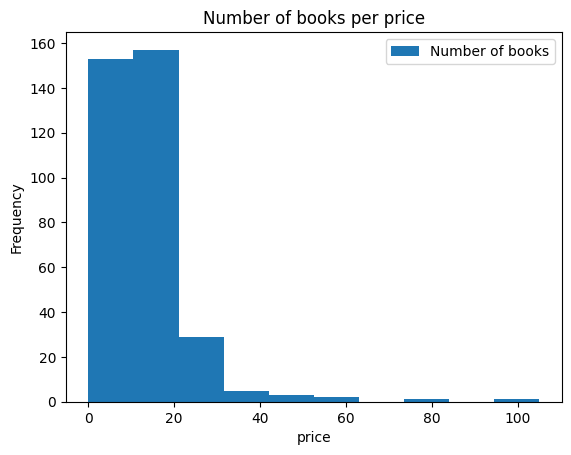

In [81]:
df['price'].plot(kind='hist', label='Number of books')

plt.xlabel('price')
plt.title('Number of books per price')
plt.legend()
plt.show()

11.Визначте, яка ціна у нас максимальна, мінімальна, середня, медіанна (використовуйте функції max, min, mean, median)

Максимальна ціна - 105

Мінімальна ціна - 0

Середня ціна - 13.1

Медіанна ціна - 11

In [82]:
df['price'].describe()

,price
count,351.000000
mean,13.076923
std,10.050860
min,0.000000
25%,8.000000
50%,12.000000
75%,16.000000
max,105.000000


In [83]:
df['price'].max()

105

In [84]:
df['price'].min()

0

In [85]:
df['price'].mean()

np.float64(13.076923076923077)

In [86]:
df['price'].median()

12.0

12.Який рейтинг у датасеті найвищий?

Відповідь: 4.9

In [87]:
df['user_rating'].max()

4.9

13.Скільки книг мають такий рейтинг?

Відповідь: 28

In [88]:
df[df['user_rating'] == 4.9]['name'].count()

np.int64(28)

14.У якої книги найбільше відгуків?

Відповідь: Where the Crawdads Sing

In [89]:
df[df['reviews'] == df['reviews'].max()]

,name,author,user_rating,reviews,price,year,genre
534,Where the Crawdads Sing,Delia Owens,4.8,87841,15,2019,Fiction


15.З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча (можна використати проміжний датафрейм)?

Відповідь: Go Set a Watchman: A Novel

In [90]:
max_price = df[df['year'] == 2015]['price'].max()
df[(df['year'] == 2015) & (df['price'] == max_price)]

,name,author,user_rating,reviews,price,year,genre
132,Go Set a Watchman: A Novel,Harper Lee,3.6,14982,19,2015,Fiction


16.Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році (використовуйте &)?

Відповідь: 17

In [91]:
df[(df['year']== 2010) & (df['genre']=='Fiction')].count()['name']

np.int64(17)

17.Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках (використовуйте | або функцію isin)?

Відповідь: 1 книга

In [92]:
df[(df['user_rating'] == 4.9) & ((df['year'] == 2010) | (df['year'] == 2011))]

,name,author,user_rating,reviews,price,year,genre
187,Jesus Calling: Enjoying Peace in His Presence ...,Sarah Young,4.9,19576,8,2011,Non Fiction


18.Відсортуємо за зростанням ціни всі книги, які потрапили в рейтинг у 2015 році і коштують дешевше за 8 доларів (використовуйте функцію sort_values).

Яка книга остання у відсортованому списку?

Відповідь: Old School (Diary of a Wimpy Kid #10)

In [93]:
df[(df['price'] < 8) & (df['year'] == 2015)].sort_values('price')

,name,author,user_rating,reviews,price,year,genre
54,Creative Haven Creative Cats Coloring Book (Ad...,Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
55,Creative Haven Owls Coloring Book (Adult Color...,Marjorie Sarnat,4.8,3871,5,2015,Non Fiction
28,Baby Touch and Feel: Animals,DK,4.6,5360,5,2015,Non Fiction
63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
89,Dover Creative Haven Art Nouveau Animal Design...,Marty Noble,4.6,2134,5,2015,Non Fiction
201,Killing Reagan: The Violent Assault That Chang...,Bill O'Reilly,4.6,5235,5,2015,Non Fiction
16,Adult Coloring Book: Stress Relieving Animal D...,Blue Star Coloring,4.6,2925,6,2015,Non Fiction
17,Adult Coloring Book: Stress Relieving Patterns,Blue Star Coloring,4.4,2951,6,2015,Non Fiction
253,Old School (Diary of a Wimpy Kid #10),Jeff Kinney,4.8,6169,7,2015,Fiction


19.Вивести максимальну та мінімальну ціни для кожного з жанрів (використовуйте функції groupby та agg, для підрахунку мінімальних та максимальних значень використовуйте maxта min). Не беріть усі стовпці, виберете тільки потрібні вам

Максимальна ціна для жанру Fiction? Відповідь: 82

Мінімальна ціна для жанру Fiction? Відповідь: 0

Максимальна ціна для жанру Non Fiction? Відповідь: 105

Мінімальна ціна для жанру Non Fiction? Відповідь: 0

In [94]:
df.groupby(['genre'])[['price']].agg([np.min, np.max])

/tmp/ipykernel_825/1401501477.py:1: FutureWarning: The provided callable <function min at 0x7a0a7c157ec0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df.groupby(['genre'])[['price']].agg([np.min, np.max])
/tmp/ipykernel_825/1401501477.py:1: FutureWarning: The provided callable <function max at 0x7a0a7c157d80> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df.groupby(['genre'])[['price']].agg([np.min, np.max])


price     
              min  max
genre                 
Fiction         0   82
Non Fiction     0  105

Висновок: Виконання цієї лабораторної дозволило на практиці розібратися з методами бібліотеки Pandas для швидкої обробки та аналізу інформації у великих масивах. Працюючи з датасетом бестселерів Amazon (2009–2019), я побудувала роботу в такому порядку:

Спочатку застосувала багатокритеріальну фільтрацію та сортування записів. Це дозволило витягнути дані про найдорожчі книги та проаналізувати зв'язок між читацьким рейтингом і кількістю залишених відгуків.

Далі через функції групування я дослідила ціновий розподіл, зафіксувавши мінімальні та максимальні показники вартості як по кожному року окремо, так і в розрізі жанрів (Fiction / Non Fiction).

Також була опрацьована сама структура таблиці: я перевірила дані на наявність пропущених значень та почистила датасет від дублікатів, щоб результати розрахунків були точними.

В результаті я переконалася, що правильне використання вбудованих функцій Pandas значно спрощує аналітику, даючи змогу швидко знаходити потрібні екстремуми та агрегувати дані без написання зайвих циклів.